# 02 — Station Flow & Imbalance
**Question:** Which stations chronically empty or overflow, and which require daily van redistribution?

Key finding: Waterloo +16% net outflow, Hop Exchange −15% inflow — 8-year structural patterns.

In [6]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

PROJECT = 'm2-dataset-study'

client = bigquery.Client(project=PROJECT)

def bq(sql):
    return client.query(sql, location='EU').to_dataframe()

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['figure.titlesize'] = 28
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['axes.titlepad'] = 20

## 2.1 — Top structurally imbalanced stations

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


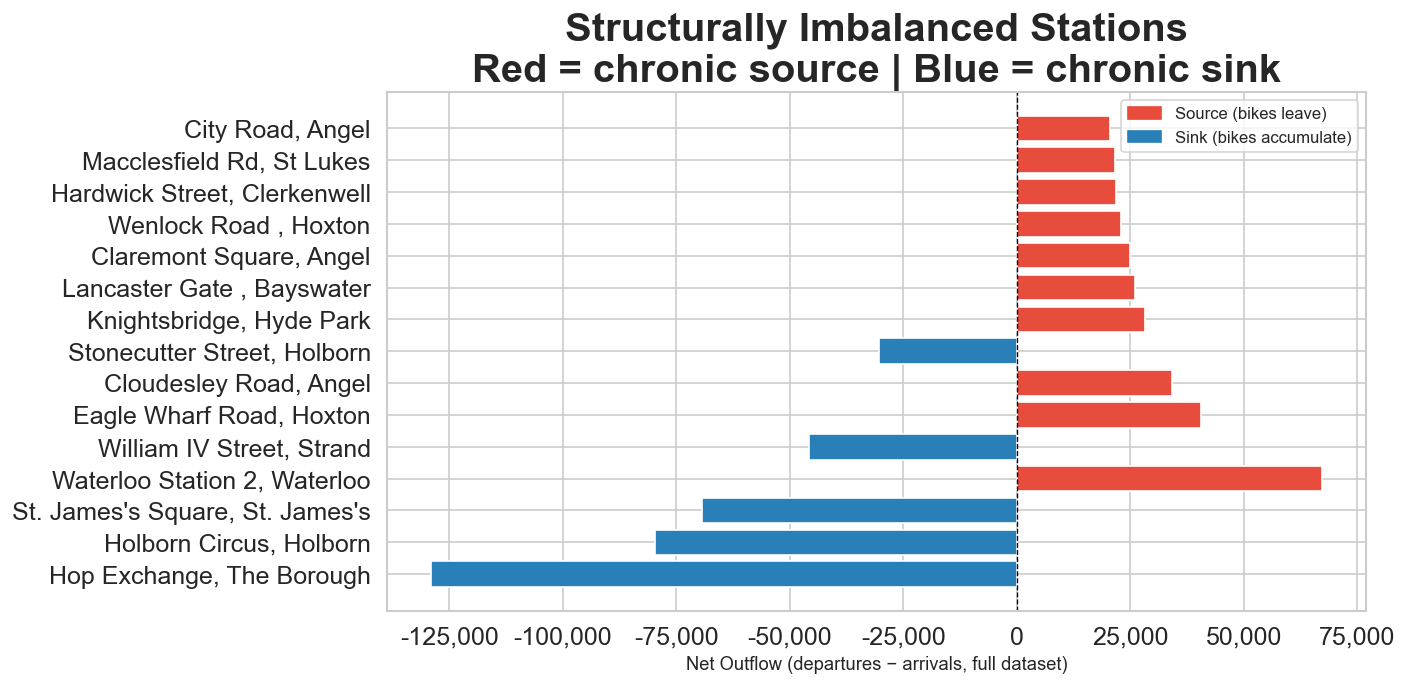

                   station_name  net_outflow  imbalance_pct flow_role
      Hop Exchange, The Borough      -128989          -15.0      sink
        Holborn Circus, Holborn       -79600          -15.5      sink
St. James's Square, St. James's       -69267          -14.3      sink
   Waterloo Station 2, Waterloo        67136           16.2    source
      William IV Street, Strand       -45762          -10.2      sink
       Eagle Wharf Road, Hoxton        40562           10.8    source
         Cloudesley Road, Angel        34065           24.2    source
    Stonecutter Street, Holborn       -30439          -15.8      sink
       Knightsbridge, Hyde Park        28307           16.6    source
     Lancaster Gate , Bayswater        26066           12.3    source
        Claremont Square, Angel        24853           22.2    source
          Wenlock Road , Hoxton        22882           10.5    source
   Hardwick Street, Clerkenwell        21854           19.5    source
      Macclesfield R

In [7]:
sql = """
SELECT
    station_name,
    total_departures,
    total_arrivals,
    net_outflow,
    ROUND(imbalance_pct, 1) AS imbalance_pct,
    flow_role
FROM `m2-dataset-study.london_bicycles_dev_dimensions.dim_station`
WHERE is_structural_imbalance
  AND NOT has_capacity_error
ORDER BY ABS(net_outflow) DESC
LIMIT 15
"""
df = bq(sql)

fig, ax = plt.subplots(figsize=(12, 6))
colours = df['flow_role'].map({'source': '#E74C3C', 'sink': '#2980B9', 'balanced': '#95A5A6'})
bars = ax.barh(df['station_name'], df['net_outflow'], color=colours)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Net Outflow (departures − arrivals, full dataset)', fontsize=11)
ax.set_title('Structurally Imbalanced Stations\nRed = chronic source | Blue = chronic sink', fontsize=24, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#E74C3C', label='Source (bikes leave)'),
    Patch(color='#2980B9', label='Sink (bikes accumulate)'),
], fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/02_station_imbalance.png', bbox_inches='tight')
plt.show()
print(df[['station_name','net_outflow','imbalance_pct','flow_role']].to_string(index=False))

## 2.2 — Hourly net flow for Waterloo vs Hop Exchange

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


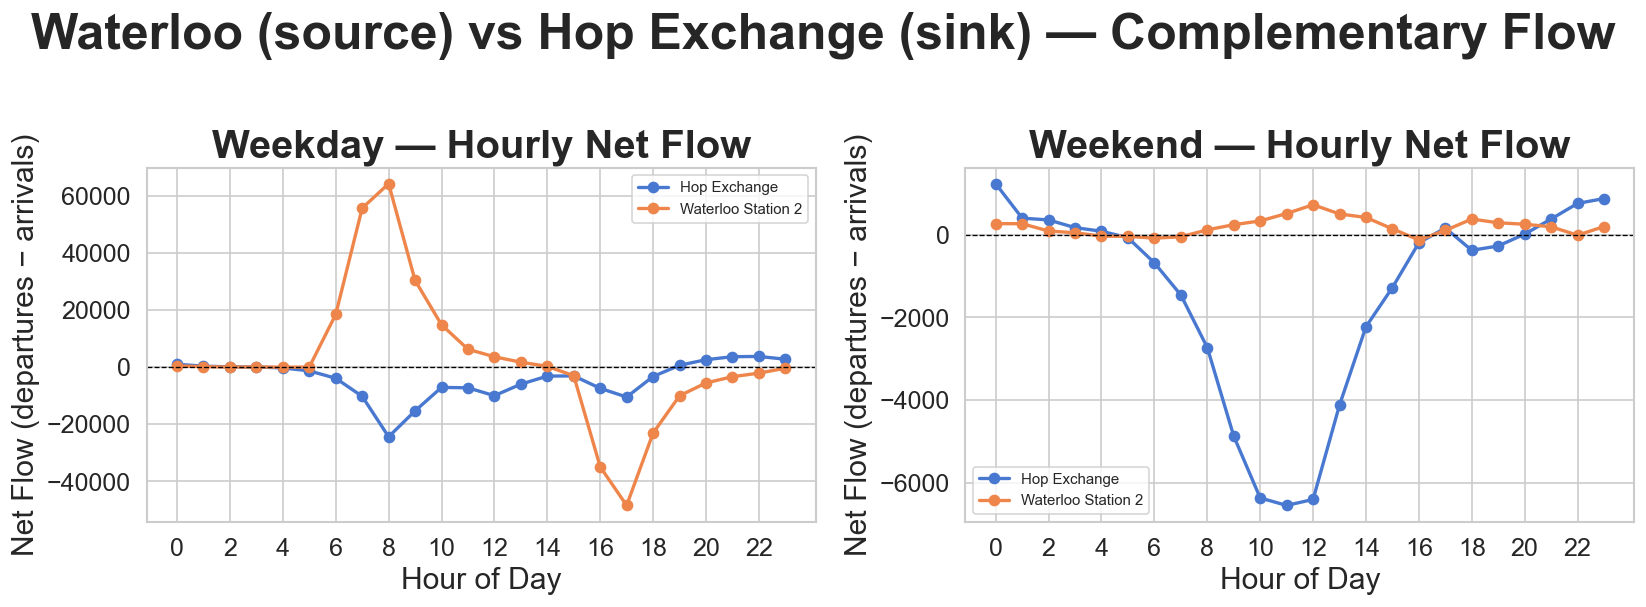

In [10]:
sql2 = """
SELECT
    station_name,
    hour_of_day,
    day_type,
    SUM(net_flow) AS net_flow
FROM `m2-dataset-study.london_bicycles_dev_marts.mart_station_demand`
WHERE station_name IN ('Waterloo Station 2, Waterloo', 'Hop Exchange, The Borough')
GROUP BY station_name, hour_of_day, day_type
ORDER BY station_name, day_type, hour_of_day
"""
df2 = bq(sql2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, day_type, colour in zip(axes, ['Weekday', 'Weekend'], ['steelblue', 'darkorange']):
    sub = df2[df2['day_type'] == day_type]
    for station, grp in sub.groupby('station_name'):
        label = station.split(',')[0]
        ax.plot(grp['hour_of_day'], grp['net_flow'], marker='o', label=label, linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{day_type} — Hourly Net Flow', fontsize=24, fontweight='bold')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Net Flow (departures − arrivals)')
    ax.legend(fontsize=9)
    ax.set_xticks(range(0, 24, 2))

plt.suptitle('Waterloo (source) vs Hop Exchange (sink) — Complementary Flow', fontsize=30, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/02_waterloo_hop_exchange_flow.png', bbox_inches='tight')
plt.show()

## 2.3 — Redistribution priority table

In [9]:
sql3 = """
SELECT
    station_name,
    total_departures,
    total_arrivals,
    net_outflow,
    ROUND(imbalance_pct, 1) AS imbalance_pct,
    flow_role,
    docks_count
FROM `m2-dataset-study.london_bicycles_dev_dimensions.dim_station`
WHERE is_structural_imbalance
  AND NOT has_capacity_error
ORDER BY ABS(net_outflow) DESC
"""
priority = bq(sql3)
priority['redistribution_action'] = priority['flow_role'].map({
    'source': 'Restock daily (bikes leave)',
    'sink':   'Empty daily (bikes pile up)'
})
print(priority[['station_name','net_outflow','imbalance_pct','redistribution_action']]
      .to_string(index=False))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


                             station_name  net_outflow  imbalance_pct       redistribution_action
                Hop Exchange, The Borough      -128989          -15.0 Empty daily (bikes pile up)
                  Holborn Circus, Holborn       -79600          -15.5 Empty daily (bikes pile up)
          St. James's Square, St. James's       -69267          -14.3 Empty daily (bikes pile up)
             Waterloo Station 2, Waterloo        67136           16.2 Restock daily (bikes leave)
                William IV Street, Strand       -45762          -10.2 Empty daily (bikes pile up)
                 Eagle Wharf Road, Hoxton        40562           10.8 Restock daily (bikes leave)
                   Cloudesley Road, Angel        34065           24.2 Restock daily (bikes leave)
              Stonecutter Street, Holborn       -30439          -15.8 Empty daily (bikes pile up)
                 Knightsbridge, Hyde Park        28307           16.6 Restock daily (bikes leave)
               Lanca